## Setup

In [1]:
%load_ext autoreload
%autoreload 2

Set up the working environment:

In [4]:
# To ensure reproducibility
seed = 7214

# Import path libraries
import os
import sys
import pathlib

# Define paths
project_path = pathlib.Path("/workspaces/TFM").resolve()
data_path = project_path / "data" / "clean" / "hatch_data.parquet"
results_path = project_path / "results" / "models" / "hatch_data"

# Add the project path to sys.path if it's not already there
if str(project_path) not in sys.path:
    sys.path.append(str(project_path))

print(f"Loading data from: {data_path}")
print(f"Saving results to: {results_path}")

Loading data from: /workspaces/TFM/data/clean/hatch_data.parquet
Saving results to: /workspaces/TFM/results/models/hatch_data


Load libraries:

In [5]:
# DATA WRANGLING, STATISTICS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
from scipy.stats import uniform, randint, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, 
                            ExtraTreesClassifier, 
                            AdaBoostClassifier, 
                            GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (roc_curve, 
                            RocCurveDisplay, 
                            roc_auc_score, 
                            precision_recall_curve,
                            average_precision_score,
                            PrecisionRecallDisplay)

# CUSTOM MODULES
from src.models import *

## Data

Load the data:

In [7]:
# Load data
df = pd.read_parquet(data_path)

# Check general structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   code           720 non-null    float64
 1   age            720 non-null    float64
 2   hypertension   720 non-null    object 
 3   COPD           720 non-null    object 
 4   stroke         720 non-null    object 
 5   heart_failure  720 non-null    object 
 6   AF_type        720 non-null    object 
 7   hatch_score    720 non-null    float64
 8   AF_recurrence  720 non-null    object 
dtypes: float64(3), object(6)
memory usage: 50.8+ KB


Let's transform the data type of categorical features and check their values:

In [8]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
    print(f"Categories of column '{col}': {df[col].cat.categories.tolist()}")

Categories of column 'hypertension': ['no', 'yes']
Categories of column 'COPD': ['no', 'yes']
Categories of column 'stroke': ['no', 'yes']
Categories of column 'heart_failure': ['no', 'yes']
Categories of column 'AF_type': ['paroxysmal', 'persistent']
Categories of column 'AF_recurrence': ['no', 'yes']


All the categorical features' values are properly arranged 

Let's separate the features from the target class:

In [9]:
# Drop the target class and the non-informative features
X = df.drop([
    "code",
    "hatch_score",
    "AF_recurrence"
            ], axis=1)

# Select the target class and encode it manually
y = df["AF_recurrence"].map({"no":0, "yes":1})

Divide data set into train ($80 \%$) and test ($20 \%$) sets :

In [10]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y,
    )

# Prevalence of the target class in the test set
prevalence = y_test.astype(int).mean()

## HATCH score evaluation

In [11]:
# Filter the patients belonging to the test group
df_test = df.loc[X_test.index]

# Get the the scores
# y_test has been already calculated
y_scores_hatch = df_test["hatch_score"]

# Compute the ROC curve and AUC
fpr_hatch, tpr_hatch, _ = roc_curve(y_test, y_scores_hatch)
roc_auc_hatch = roc_auc_score(y_test, y_scores_hatch)
print(f"ROC-AUC for HATCH score: {roc_auc_hatch:.4f}")

# Compute the PR curve and AUC
precs_hatch, recs_hatch, _ = precision_recall_curve(y_test, y_scores_hatch)
pr_auc_hatch = average_precision_score(y_test, y_scores_hatch)
print(f"PR-AUC for HATCH score: {pr_auc_hatch:.4f}")

ROC-AUC for HATCH score: 0.5347
PR-AUC for HATCH score: 0.4174


ROC and PR curves:

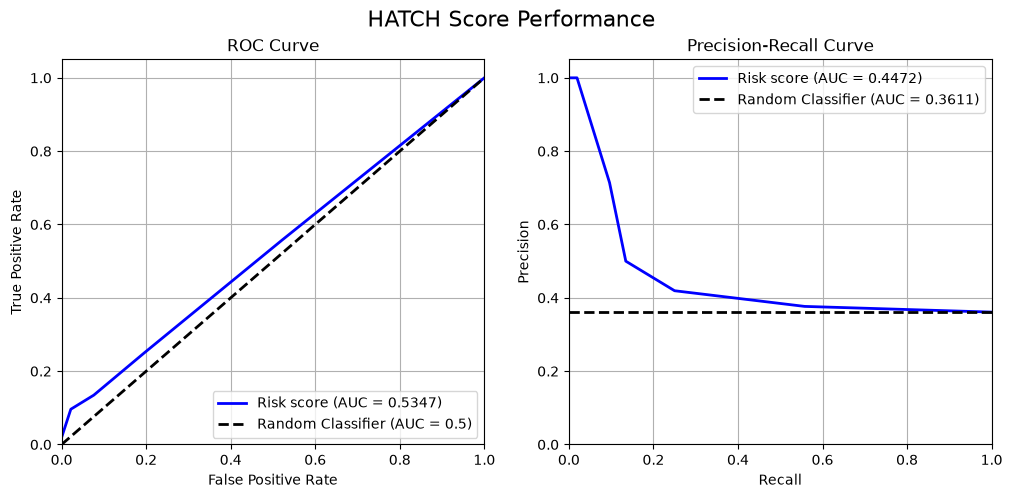

In [12]:
plot_risk_score_curves(fpr_hatch, tpr_hatch, recs_hatch, precs_hatch, 
                        title='HATCH Score Performance', prevalence=prevalence,
                        output_dir=results_path)

## Training and optimization

Training each model with stratified 5-fold cross validation:

In [13]:
# Number of trials per model
n_trials = 150

# Number of splits
n_cv = 5

# Cross-validation strategy
my_cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=42)

Define metrics to evaluate:

In [14]:
# Set up the scoring dictionary for cross-validation
scoring_dict = {
        'ROC-AUC': 'roc_auc',
        'PR-AUC': 'average_precision'
    }

objective_metric = "PR-AUC"

#### Logistic Regression (Elastic Net)

Define the parameter distributions and set up the pipeline:

In [15]:
# Get the preprocessor
preprocessor_EN = get_full_preprocessor(X_train, seed=seed)

# Full pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor_EN),
    ('clf', LogisticRegression(random_state=seed, solver='saga', max_iter=10000))
])

# Hyperparameters search space
params_EN = {
    'clf__l1_ratio': uniform(0, 1),
    'clf__C': loguniform(1e-4, 1e3)
    }

Train and optimize the model:

In [16]:
(
optimized_EN, 
cv_results_EN,
fpr_EN, tpr_EN,
precs_EN, recs_EN
) = optimize_model_random_search(
    pipeline=pipe_EN, 
    param_distributions=params_EN, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    aim=scoring_dict[objective_metric],
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 150 candidates, totalling 750 fits


Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [17]:
save_model(fitted_pipeline=optimized_EN, output_dir=results_path, identifier="EN")

,Hyperparameter,Optimal Value
1,C,0.160301
2,dual,False
3,fit_intercept,True
4,intercept_scaling,1
5,l1_ratio,0.61177
6,max_iter,10000
7,penalty,deprecated
8,random_state,7214
9,solver,saga
10,tol,0.0001


Check the overfitting:

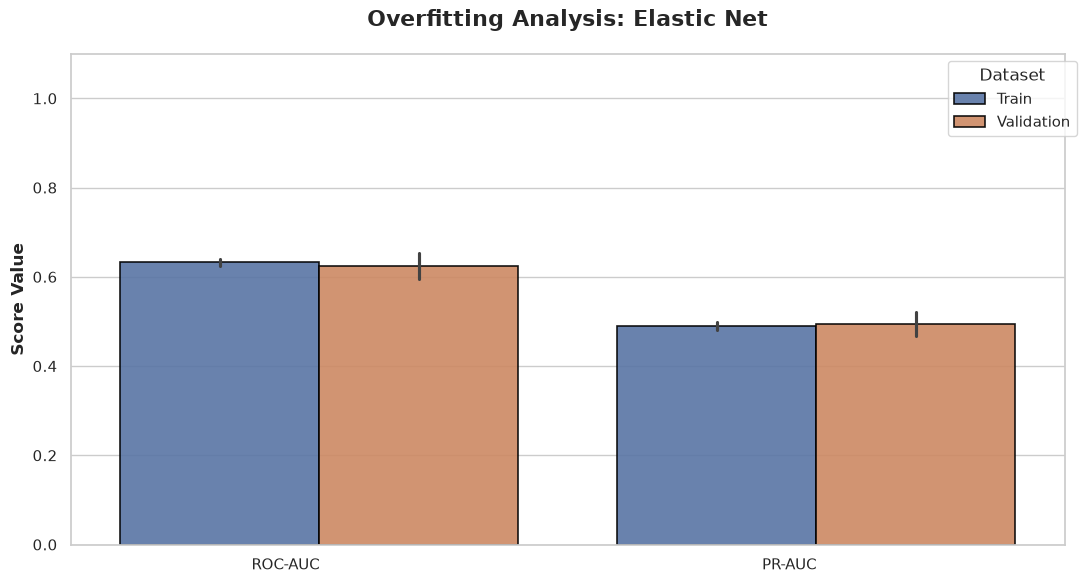

In [18]:
plot_overfitting_bars(df_cv_results=cv_results_EN, 
                    title="Elastic Net", 
                    output_dir=results_path, 
                    identifier="EN")

Take a look at the relevant columns:

In [19]:
relevant_cols, irrelevant_cols = get_relevant_features(optimized_EN)

print("relevant features: ", relevant_cols)
print("\n")
print("irrelevant features: ", irrelevant_cols)

relevant features:  ['AF_type', 'age', 'stroke', 'hypertension', 'heart_failure']


irrelevant features:  ['COPD']


Drop irrelevant features from the data set:

In [ ]:
X_train_filtered = X_train.drop(columns=irrelevant_cols)
X_test_filtered = X_test.drop(columns=irrelevant_cols)

#### Support Vector Machine

Define the parameter distributions and set up the pipeline:

In [ ]:
# Get preprocessor
preprocessor_SVM = get_full_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor_SVM),
    ('clf', SVC(random_state=seed, max_iter=10000))
])

# Hyperparameters search space
params_dist_SVM = {
    'clf__C': loguniform(1e-5, 1e3),
    'clf__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'clf__gamma': ['scale', 'auto'] + list(np.logspace(-4, 1, 50)),
    'clf__degree': randint(2, 4),
    'clf__class_weight': [None, 'balanced']
}


Train and optimize the model:

In [ ]:
(
optimized_SVM, 
cv_results_SVM,
fpr_SVM, tpr_SVM,
precs_SVM, recs_SVM
) = optimize_model_random_search(
    pipeline=pipe_SVM, 
    param_distributions=params_dist_SVM, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 150 candidates, totalling 750 fits


/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/

Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [23]:
save_model(fitted_pipeline=optimized_SVM, output_dir=results_path, identifier="SVM")

,Hyperparameter,Optimal Value
1,C,0.000243
2,break_ties,False
3,cache_size,200
4,class_weight,balanced
5,coef0,0.0
6,decision_function_shape,ovr
7,degree,2
8,gamma,0.013895
9,kernel,rbf
10,max_iter,10000


Check the overfitting:

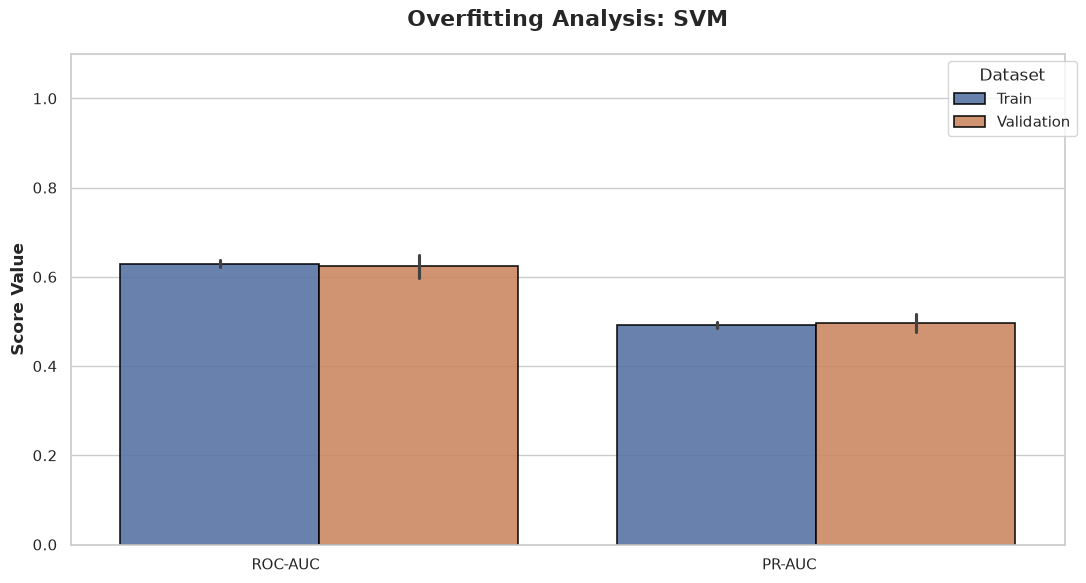

In [24]:
plot_overfitting_bars(df_cv_results=cv_results_SVM, 
                    title="SVM", 
                    output_dir=results_path, 
                    identifier="SVM")

#### Decision Tree

Define the parameter distributions and set up the pipeline:

In [ ]:
# Get the preprocessor
preprocessor_DT = get_trees_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_DT = Pipeline(steps=[
    ('preprocessor', preprocessor_DT),
    ('clf', DecisionTreeClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_DT = {
    'clf__max_depth': randint(2, 33),
    'clf__max_features': ['sqrt', 'log2', None] + list(np.arange(0.1, 1.1, 0.1)),
    'clf__min_samples_split': randint(2, 21),
    'clf__criterion': ['gini', 'entropy'],
}

Train and optimize the model:

In [ ]:
(
optimized_DT, 
cv_results_DT,
fpr_DT, tpr_DT,
precs_DT, recs_DT
) = optimize_model_random_search(
    pipeline=pipe_DT, 
    param_distributions=params_dist_DT, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [27]:
save_model(fitted_pipeline=optimized_DT, output_dir=results_path, identifier="DT")

,Hyperparameter,Optimal Value
1,ccp_alpha,0.0
2,criterion,gini
3,max_depth,9
4,max_features,0.7
5,min_impurity_decrease,0.0
6,min_samples_leaf,1
7,min_samples_split,19
8,min_weight_fraction_leaf,0.0
9,random_state,7214
10,splitter,best


Check the overfitting:

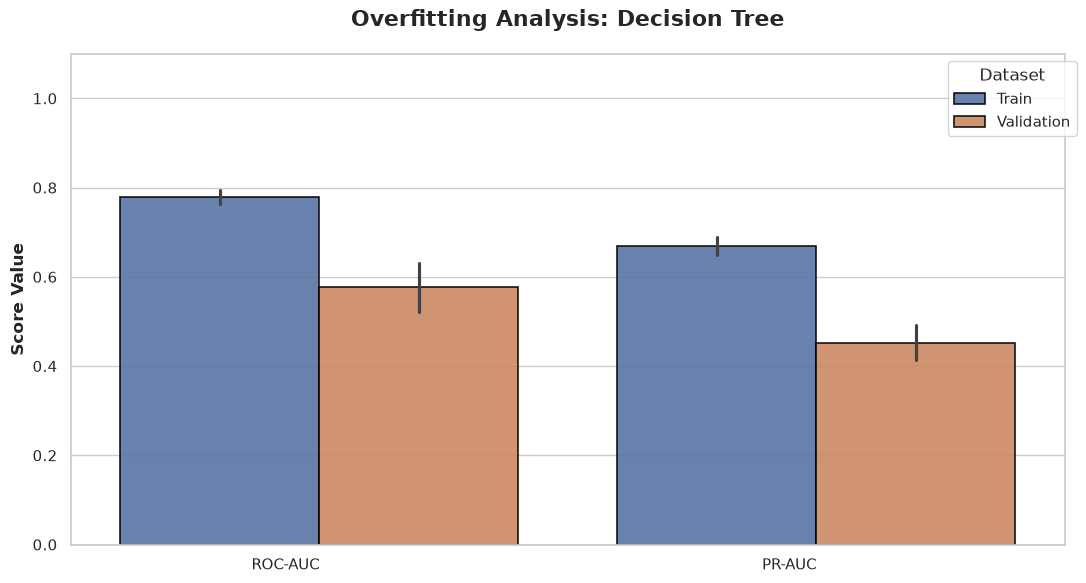

In [28]:
plot_overfitting_bars(df_cv_results=cv_results_DT, 
                    title="Decision Tree", 
                    output_dir=results_path, 
                    identifier="DT")

#### Random Forest

Define the parameter distributions and set up the pipeline:

In [ ]:
# Get the preprocessor
preprocessor_RF = get_trees_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_RF),
    ('clf', RandomForestClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_RF = {
    # Decision trees hyperparameters
    'clf__max_depth': [None] + list(range(2, 20)),
    'clf__max_features': ['sqrt', 'log2', None] + list(np.arange(0.2, 0.9, 0.1)),
    'clf__min_samples_split': randint(2, 20),
    'clf__min_samples_leaf': randint(1, 10), # NUEVO: Previene hojas con 1 solo paciente
    'clf__criterion': ['gini', 'entropy'],
    
    # Ensemble bagging hyperparameters
    'clf__n_estimators': randint(50, 500), # Mejor empezar en 50, 10 árboles son muy pocos para RF
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}

Train and optimize the model:

In [ ]:
(
optimized_RF, 
cv_results_RF,
fpr_RF, tpr_RF,
precs_RF, recs_RF
) = optimize_model_random_search(
    pipeline=pipe_RF, 
    param_distributions=params_dist_RF, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [31]:
save_model(fitted_pipeline=optimized_RF, output_dir=results_path, identifier="RF")

,Hyperparameter,Optimal Value
1,bootstrap,True
2,ccp_alpha,0.0
3,class_weight,balanced_subsample
4,criterion,entropy
5,max_depth,2
6,max_features,0.3
7,min_impurity_decrease,0.0
8,min_samples_leaf,9
9,min_samples_split,19
10,min_weight_fraction_leaf,0.0


Check the overfitting:

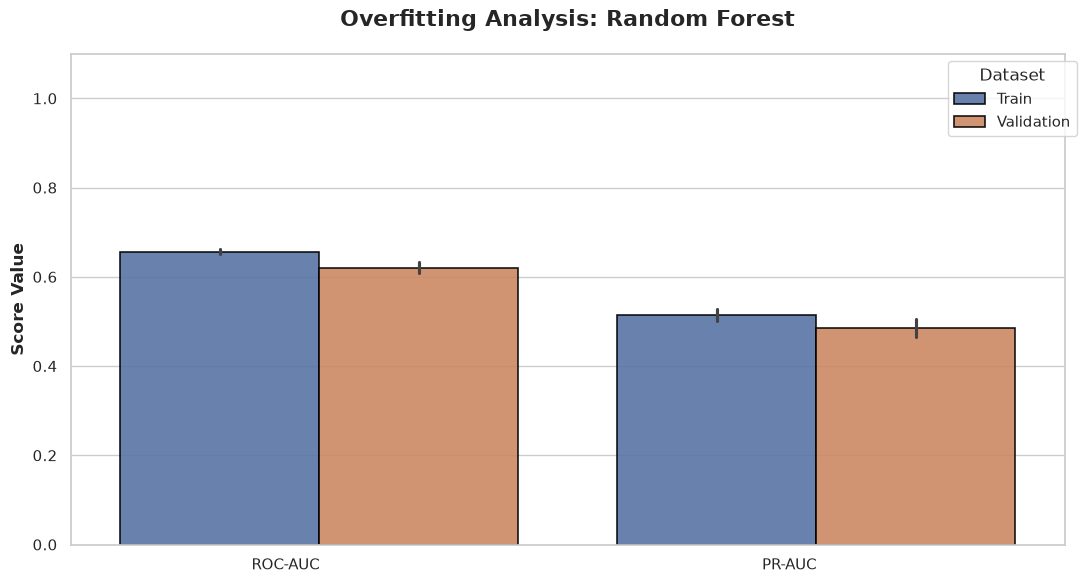

In [32]:
plot_overfitting_bars(df_cv_results=cv_results_RF, 
                    title="Random Forest", 
                    output_dir=results_path, 
                    identifier="RF")

#### Extra Trees


Define the parameter distributions and set up the pipeline:


In [ ]:
# Get the preprocessor (using the same as RF)
preprocessor_ET = get_trees_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_ET = Pipeline(steps=[
    ('preprocessor', preprocessor_ET),
    ('clf', ExtraTreesClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_ET = {
    # Decision trees hyperparameters
    'clf__max_depth': [None] + list(range(2, 20)),
    'clf__max_features': ['sqrt', 'log2', None] + list(np.arange(0.2, 0.9, 0.1)),
    'clf__min_samples_split': randint(2, 20),
    'clf__min_samples_leaf': randint(1, 10), # NUEVO: Previene hojas con 1 solo paciente
    'clf__criterion': ['gini', 'entropy'],
    
    # Ensemble bagging hyperparameters
    'clf__n_estimators': randint(50, 500), # Mejor empezar en 50, 10 árboles son muy pocos para RF
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}

Train and optimize the model:


In [ ]:
(
optimized_ET, 
cv_results_ET,
fpr_ET, tpr_ET,
precs_ET, recs_ET
) = optimize_model_random_search(
    pipeline=pipe_ET, 
    param_distributions=params_dist_ET, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:


In [35]:
save_model(fitted_pipeline=optimized_ET, output_dir=results_path, identifier="ET")


,Hyperparameter,Optimal Value
1,bootstrap,False
2,ccp_alpha,0.0
3,criterion,entropy
4,max_depth,2
5,max_features,0.2
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,4
9,min_weight_fraction_leaf,0.0
10,n_estimators,369


Check the overfitting:


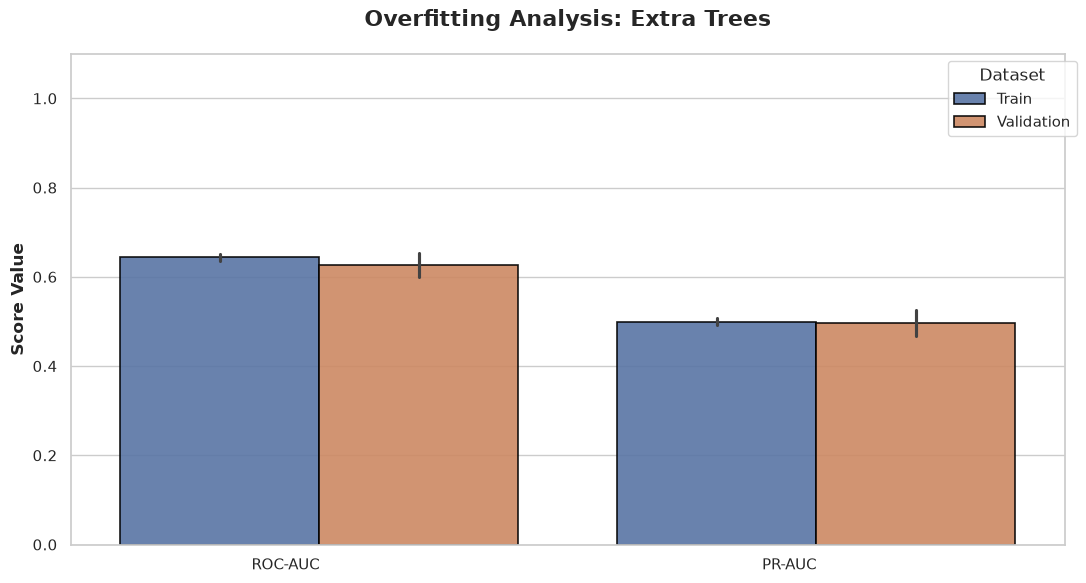

In [36]:
plot_overfitting_bars(df_cv_results=cv_results_ET, 
                    title="Extra Trees", 
                    output_dir=results_path, 
                    identifier="ET")


#### Adaptative Boosting

Define the parameter distributions and set up the pipeline:

In [ ]:
# Get the preprocessor
preprocessor_AB = get_trees_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_AB = Pipeline(steps=[
    ('preprocessor', preprocessor_AB),
    ('clf', AdaBoostClassifier(random_state=seed, 
                            estimator=DecisionTreeClassifier(random_state=seed)))
])

# Hyperparameters search space
params_dist_AB = {
    # Decision trees hyperparameters
    'clf__estimator__max_depth': randint(1, 4), # Profundidad 1 (stump), 2 o 3 máximo
    'clf__estimator__max_features': ['sqrt', 'log2', None],
    'clf__estimator__min_samples_split': randint(2, 10),
    'clf__estimator__criterion': ['gini', 'entropy'],
    
    # Ensemble boosting hyperparameters
    'clf__n_estimators': randint(50, 500),
    'clf__learning_rate': loguniform(0.001, 1.0) 
}

Train and optimize the model:

In [ ]:
(
optimized_AB, 
cv_results_AB,
fpr_AB, tpr_AB,
precs_AB, recs_AB
) = optimize_model_random_search(
    pipeline=pipe_AB, 
    param_distributions=params_dist_AB, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [39]:
save_model(fitted_pipeline=optimized_AB, output_dir=results_path, identifier="AB")

,Hyperparameter,Optimal Value
1,estimator__ccp_alpha,0.0
2,estimator__criterion,entropy
3,estimator__max_depth,3
4,estimator__min_impurity_decrease,0.0
5,estimator__min_samples_leaf,1
6,estimator__min_samples_split,9
7,estimator__min_weight_fraction_leaf,0.0
8,estimator__random_state,7214
9,estimator__splitter,best
10,estimator,"DecisionTreeClassifier(criterion='entropy', ma..."


Check the overfitting:

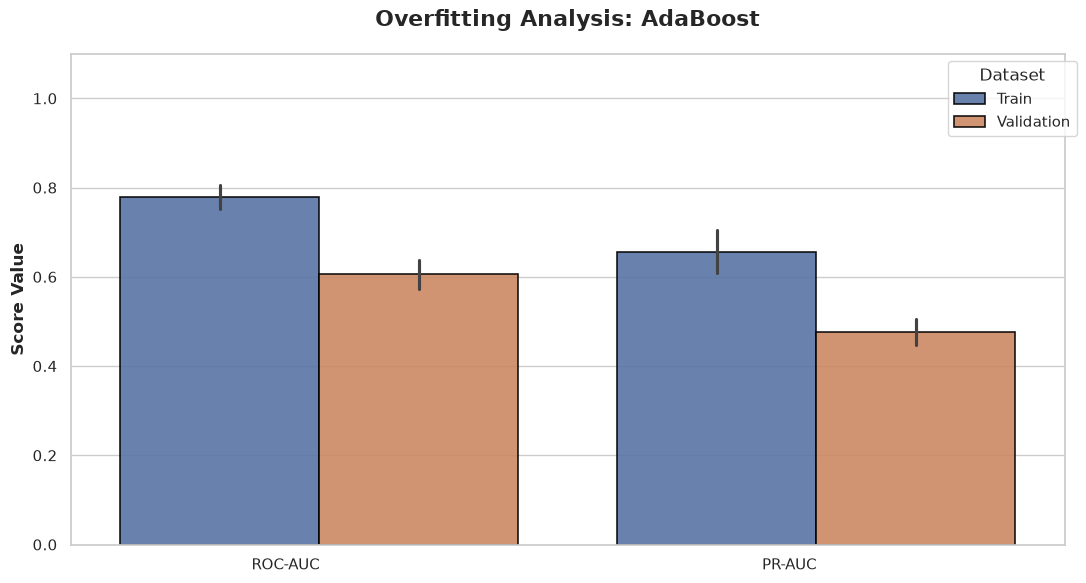

In [40]:
plot_overfitting_bars(df_cv_results=cv_results_AB, 
                    title="AdaBoost", 
                    output_dir=results_path, 
                    identifier="AB")

#### Gradient Boosting

Define the parameter distributions and set up the pipeline:

In [ ]:
# Get the preprocessor
preprocessor_GB = get_trees_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_GB = Pipeline(steps=[
    ('preprocessor', preprocessor_GB),
    ('clf', GradientBoostingClassifier(
        random_state=seed 
    ))
])

params_dist_GB = {
    # Decision trees hyperparameters
    'clf__max_depth': randint(2, 6),
    'clf__max_features': ['sqrt', 'log2', None] + list(np.arange(0.2, 0.9, 0.1)),
    'clf__min_samples_split': randint(2, 20),
    'clf__min_samples_leaf': randint(1, 10),
    
    # Ensemble boosting hyperparameters
    'clf__n_estimators': randint(50, 500),
    'clf__learning_rate': loguniform(0.005, 0.5),
    'clf__subsample': uniform(0.5, 0.5)
}

Train and optimize the model:

In [ ]:
(
optimized_GB, 
cv_results_GB,
fpr_GB, tpr_GB,
precs_GB, recs_GB
) = optimize_model_random_search(
    pipeline=pipe_GB, 
    param_distributions=params_dist_GB, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 150 candidates, totalling 750 fits


Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [43]:
save_model(fitted_pipeline=optimized_GB, output_dir=results_path, identifier="GB")

,Hyperparameter,Optimal Value
1,ccp_alpha,0.0
2,criterion,deprecated
3,learning_rate,0.007251
4,loss,log_loss
5,max_depth,2
6,max_features,0.3
7,min_impurity_decrease,0.0
8,min_samples_leaf,2
9,min_samples_split,12
10,min_weight_fraction_leaf,0.0


Check the overfitting:

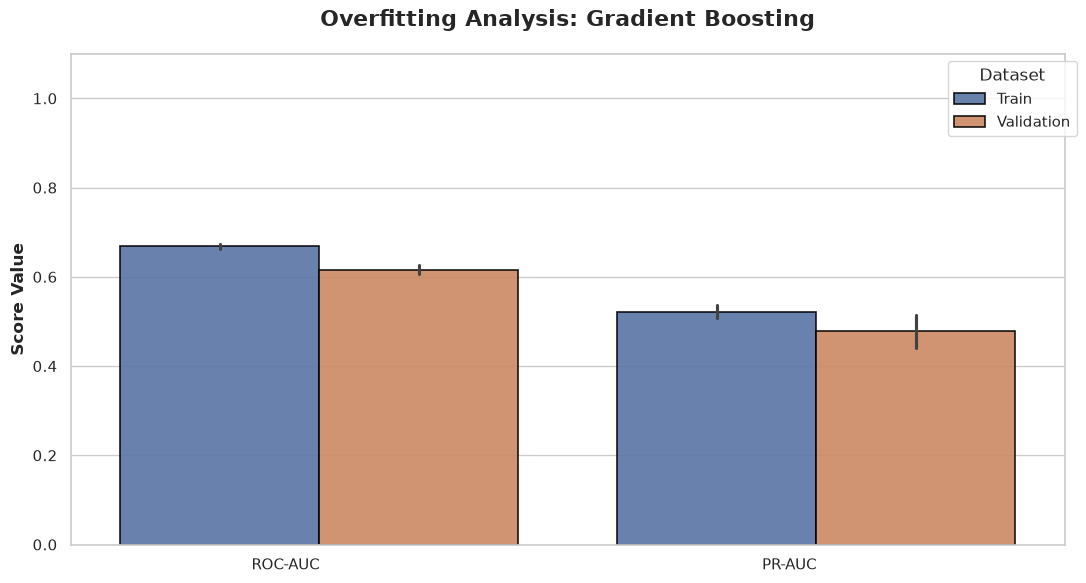

In [44]:
plot_overfitting_bars(df_cv_results=cv_results_GB, 
                    title="Gradient Boosting", 
                    output_dir=results_path, 
                    identifier="GB")

#### Multi-Layer Perceptron

Define the parameter distributions and set up the pipeline:

In [ ]:
# Get the preprocessor
preprocessor_MLP = get_full_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_MLP = Pipeline(steps=[
    ('preprocessor', preprocessor_MLP),
    ('clf', MLPClassifier(random_state=seed, max_iter=1000, early_stopping=True, validation_fraction=0.1))
])

# Hyperparameters search space
params_dist_MLP = {
    'clf__hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100), (200, 100)],
    'clf__alpha': loguniform(1e-5, 1e-1),
    'clf__learning_rate_init': loguniform(0.001, 0.01),
    'clf__batch_size': np.logspace(start = 0, stop = 6, base = 2, num = 7).astype(int).tolist(),
    'clf__activation': ['relu', 'tanh', 'logistic'],
    'clf__solver': ['adam', 'sgd']
}

Train and optimize the model:

In [ ]:
(
optimized_MLP, 
cv_results_MLP,
fpr_MLP, tpr_MLP,
precs_MLP, recs_MLP
) = optimize_model_random_search(
    pipeline=pipe_MLP, 
    param_distributions=params_dist_MLP, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Evaluating on the training set...
Evaluating on the test set...


Save the optimized model and check the hyperparameters:

In [47]:
save_model(fitted_pipeline=optimized_MLP, output_dir=results_path, identifier="MLP")


,Hyperparameter,Optimal Value
1,activation,tanh
2,alpha,0.014847
3,batch_size,16
4,beta_1,0.9
5,beta_2,0.999
6,early_stopping,True
7,epsilon,0.0
8,hidden_layer_sizes,"(100, 100)"
9,learning_rate,constant
10,learning_rate_init,0.009076


Check the overfitting:

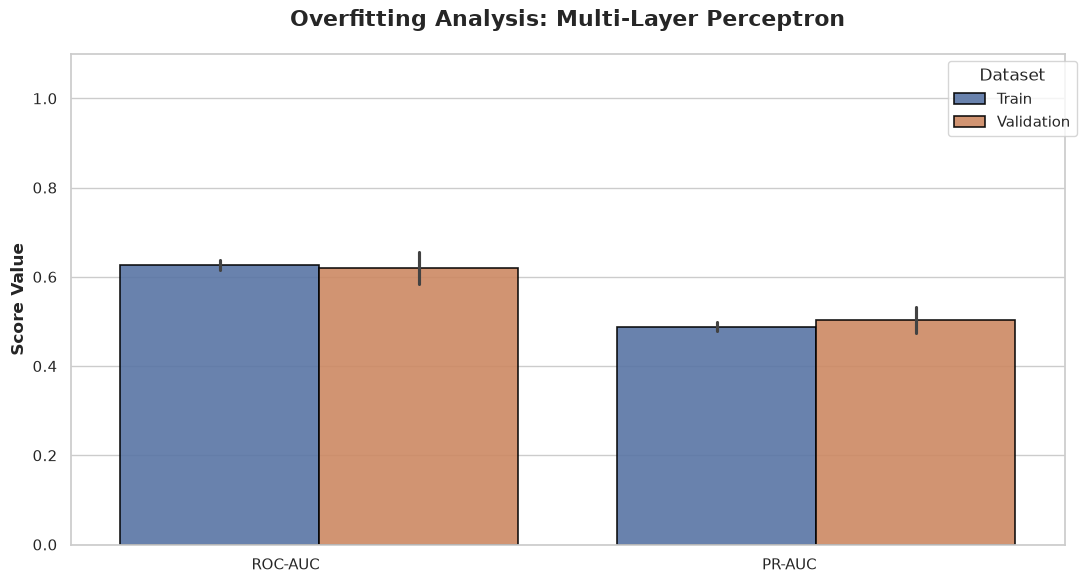

In [48]:
plot_overfitting_bars(df_cv_results=cv_results_MLP, 
                    title="Multi-Layer Perceptron", 
                    output_dir=results_path, 
                    identifier="MLP")


## Save results

In [49]:
models = ["Elastic Net", "SVM", "Decision Tree", "Random Forest", "Extra Trees", "AdaBoost", "Gradient Boost", "MLP"]

models_dict = {
    "Elastic Net": cv_results_EN,
    "SVM": cv_results_SVM,
    "Decision Tree": cv_results_DT,
    "Random Forest": cv_results_RF,
    "Extra Trees": cv_results_ET,
    "AdaBoost": cv_results_AB,
    "Gradient Boost": cv_results_GB,
    "MLP": cv_results_MLP
}


### Main metrics

In [50]:
results = save_metrics_results(models_dict=models_dict, output_dir=results_path)

results.head()

,Model,Metric,Dataset,Score
0,Elastic Net,ROC-AUC,Train,0.636539
1,Elastic Net,ROC-AUC,Validation,0.617761
2,Elastic Net,ROC-AUC,Train,0.639089
3,Elastic Net,ROC-AUC,Validation,0.599539
4,Elastic Net,ROC-AUC,Train,0.620209


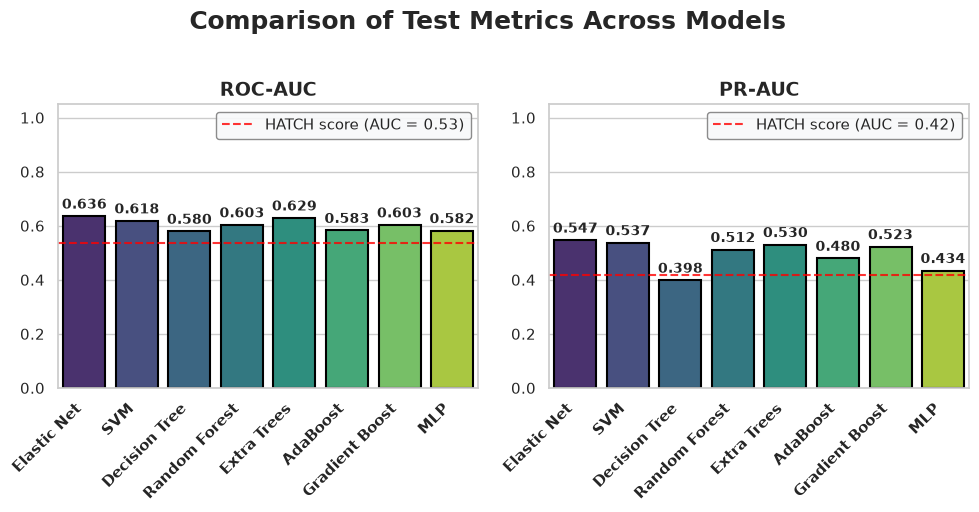

In [51]:
plot_metrics_bars(results, 
                metrics=['ROC-AUC', 'PR-AUC'],
                baselines=[roc_auc_hatch, pr_auc_hatch],
                output_dir=results_path)

### ROC and PR curves

Join the metrics into a csv file:

In [52]:
# Save the false/true positive rates values into a csv
fpr = [fpr_EN, fpr_SVM, fpr_DT, fpr_RF, fpr_ET, fpr_AB, fpr_GB, fpr_MLP]
tpr = [tpr_EN, tpr_SVM, tpr_DT, tpr_RF, tpr_ET, tpr_AB, tpr_GB, tpr_MLP]

roc_results = save_curves_results(models, fpr, tpr, curve_type='roc', 
                                output_dir=results_path)

# Save the precision and recall values for the PR curves into a csv
precs = [precs_EN, precs_SVM, precs_DT, precs_RF, precs_ET, precs_AB, precs_GB, precs_MLP]
recs = [recs_EN, recs_SVM, recs_DT, recs_RF, recs_ET, recs_AB, recs_GB, recs_MLP]

pr_results = save_curves_results(models, recs, precs, curve_type='pr', 
                                output_dir=results_path)


Plot ROC curves:

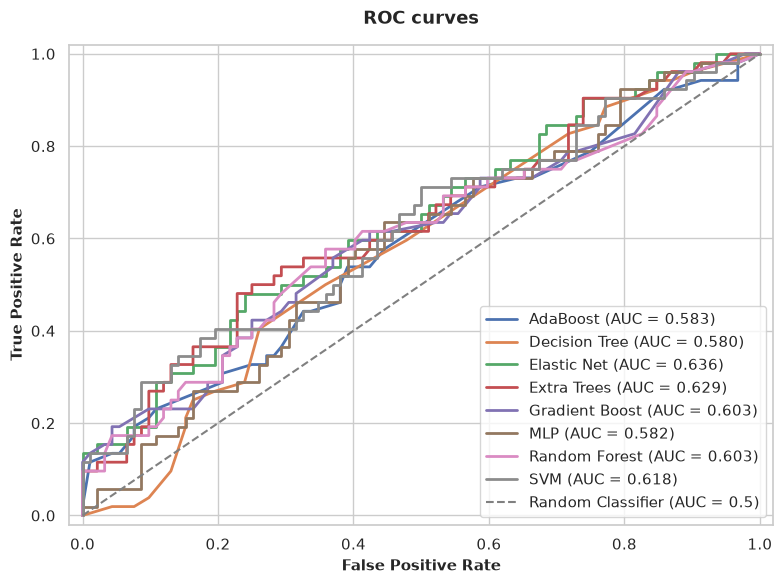

In [53]:
plot_model_curves(roc_results, 
                x_col='False Positive Rate', y_col='True Positive Rate', 
                curve_type='roc', title="ROC curves",
                output_dir=results_path)

Plot PR curves:

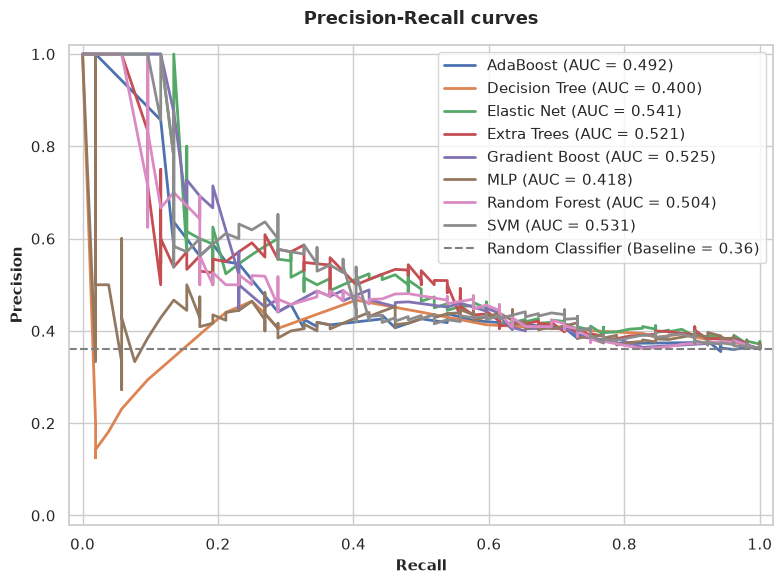

In [54]:
# Use the actual prevalence for the random classifier baseline
test_prevalence = y_test.astype(float).mean()

plot_model_curves(pr_results, 
                x_col='Recall', y_col='Precision', 
                curve_type='pr', title="Precision-Recall curves",
                prevalence=test_prevalence,
                output_dir=results_path)


Comparison HATCH score vs my best model:

In [55]:
# Compute elastic net AUC individually
y_pred_EN = optimized_EN.predict_proba(X_test)[:, 1]

roc_auc_EN = roc_auc_score(y_test, y_pred_EN)
pr_auc_EN = average_precision_score(y_test, y_pred_EN)

# Set up the figure
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot ROC curves for each model
ax[0].plot(fpr_hatch, tpr_hatch, label='HATCH score (AUC = {:.4f})'.format(roc_auc_hatch))
ax[0].plot(fpr_EN, tpr_EN, label='Elastic Net (AUC = {:.4f})'.format(roc_auc_EN))
ax[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curves')
ax[0].legend(loc='lower right')

# Plot Precision-Recall curves for each model
ax[1].plot(recs_hatch, precs_hatch, label='HATCH score (AUC = {:.4f})'.format(pr_auc_hatch))
ax[1].plot(recs_EN, precs_EN, label='Elastic Net (AUC = {:.4f})'.format(pr_auc_EN))
ax[1].axhline(y=test_prevalence, color='k', linestyle='--', label='Random Classifier')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curves')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

ValueError: columns are missing: {'COPD'}